### IMPORTS

In [32]:
import pandas as pd
import numpy as np
from math import sqrt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFE

### LOADING DATA

In [2]:
DATA = pd.read_csv('nyc_taxi_trip_duration.csv')

In [3]:
DATA.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


### MISSING VALUES

In [4]:
DATA.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

### ONE HOT ENCODING

#### STORE AND FORWARD FLAG

In [5]:
DATA = pd.concat([pd.get_dummies(DATA['store_and_fwd_flag']), DATA], axis = 1)

In [6]:
DATA = DATA.drop(['store_and_fwd_flag'], axis = 1)

#### VENDOR ID

In [7]:
DATA = pd.concat([pd.get_dummies(DATA['vendor_id'], prefix = 'vendor'), DATA], axis = 1)

In [8]:
DATA = DATA.drop(['vendor_id'], axis = 1)

In [9]:
DATA.head()

,vendor_1,vendor_2,N,Y,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,0,1,1,0,id1080784,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,400
1,1,0,1,0,id0889885,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,1100
2,0,1,1,0,id0857912,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,1635
3,0,1,1,0,id3744273,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,1141
4,1,0,1,0,id0232939,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,848


### FEATURE ENGINEERING

#### PICKUP DATETIME

In [10]:
DATA['pickup_datetime'] = pd.to_datetime(DATA['pickup_datetime'])

In [11]:
DATA['pickup_weekday'] = DATA['pickup_datetime'].dt.weekday

In [12]:
DATA['pickup_weekofyear'] = DATA['pickup_datetime'].dt.isocalendar().week

In [13]:
DATA['pickup_hour'] = DATA['pickup_datetime'].dt.hour

In [14]:
DATA['pickup_minute'] = DATA['pickup_datetime'].dt.minute

In [15]:
DATA['pickup_dt'] = (DATA['pickup_datetime'] - DATA['pickup_datetime'].min()).dt.total_seconds()

In [16]:
DATA['pickup_week_hour'] = DATA['pickup_weekday'] * 24 + DATA['pickup_hour']

In [17]:
DATA = DATA.drop(['pickup_datetime'], axis = 1)

#### DISTANCE

In [18]:
dlon = DATA["pickup_longitude"] - DATA["dropoff_longitude"]
dlat = DATA["pickup_latitude"] - DATA["dropoff_latitude"]
a = (np.sin(dlat/2))**2 + np.cos(DATA["pickup_latitude"]) * np.cos(DATA["dropoff_latitude"]) * (np.sin(dlon/2))**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
DATA["distance"] = 6373.0 * c

#### BINNING

In [19]:
DATA['pickup_latitude_round3'] = np.round(DATA['pickup_latitude'],3)
DATA['pickup_longitude_round3'] = np.round(DATA['pickup_longitude'],3)

In [20]:
DATA['dropoff_latitude_round3'] = np.round(DATA['dropoff_latitude'],3)
DATA['dropoff_longitude_round3'] = np.round(DATA['dropoff_longitude'],3)

#### TIME DURATION

In [1]:
sns.displot(DATA['trip_duration'], kde = False, bins = 25)

NameError: name 'sns' is not defined

##### Normalize trip duration

In [22]:
DATA['trip_duration'] = np.log1p(DATA['trip_duration'])

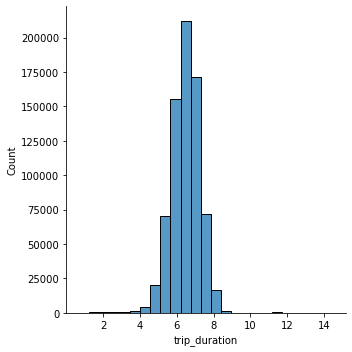

In [23]:
sns.displot(DATA['trip_duration'], kde = False, bins = 25)

In [24]:
DATA.head()

,vendor_1,vendor_2,N,Y,id,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,...,pickup_weekofyear,pickup_hour,pickup_minute,pickup_dt,pickup_week_hour,distance,pickup_latitude_round3,pickup_longitude_round3,dropoff_latitude_round3,dropoff_longitude_round3
0,0,1,1,0,id1080784,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,...,9,16,40,5157547.0,16,80.142332,40.779,-73.954,40.771,-73.964
1,1,0,1,0,id0889885,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,...,10,23,35,6132863.0,119,238.106427,40.732,-73.988,40.695,-73.995
2,0,1,1,0,id0857912,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,...,7,17,59,4471099.0,161,462.455755,40.721,-73.997,40.775,-73.948
3,0,1,1,0,id3744273,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,...,1,9,44,380597.0,33,136.827598,40.760,-73.962,40.781,-73.957
4,1,0,1,0,id0232939,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,...,7,6,42,4084869.0,54,274.888260,40.708,-74.017,40.741,-73.988


### TRAIN / TEST SPLIT

In [25]:
X = DATA.drop(['id', 'dropoff_datetime', 'trip_duration'], axis = 1)
cols = X.columns
y = DATA['trip_duration']

In [26]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=11)

### MODEL

In [27]:
def cv_score(ml_model, cols = X.columns):
    i = 1
    
    kf = KFold(n_splits=5,random_state=11,shuffle=True)
    
    for train_index,test_index in kf.split(X[cols], y):
        
        xtr,xvl = X[cols].loc[train_index], X[cols].loc[test_index]
        ytr,yvl = y[train_index], y[test_index]

        model = ml_model
        model.fit(xtr, ytr)
        
        train_val = model.predict(xtr)
        pred_val = model.predict(xvl)
        rmse_score_train = sqrt(mean_squared_error(ytr, train_val))
        rmse_score = sqrt(mean_squared_error(yvl, pred_val))
        
        print('{} of kfold {} RMSE Train {:.5f} RMSE Test {:.5f}'.format(i, kf.n_splits, rmse_score_train, rmse_score))
        i+=1

In [28]:
cv_score(LinearRegression())

1 of kfold 5 RMSE Train 0.62558 RMSE Test 0.62357
2 of kfold 5 RMSE Train 0.62501 RMSE Test 0.62581
3 of kfold 5 RMSE Train 0.62473 RMSE Test 0.62753
4 of kfold 5 RMSE Train 0.62004 RMSE Test 0.72420
5 of kfold 5 RMSE Train 0.62641 RMSE Test 0.62029


In [29]:
cv_score(DecisionTreeRegressor(min_samples_leaf=25, min_samples_split=25))

1 of kfold 5 RMSE Train 0.38118 RMSE Test 0.44408
2 of kfold 5 RMSE Train 0.38100 RMSE Test 0.44619
3 of kfold 5 RMSE Train 0.38332 RMSE Test 0.43718
4 of kfold 5 RMSE Train 0.38289 RMSE Test 0.44081
5 of kfold 5 RMSE Train 0.38274 RMSE Test 0.44072


### REVERSE FEATURE ELIMINATION

#### LINEAR REGRESSION

In [31]:
rfe = RFE(estimator = LinearRegression(), n_features_to_select=1, step=1)
rfe.fit(X, y)

RFE(estimator=LinearRegression(), n_features_to_select=1)

In [33]:
ranking_df = pd.DataFrame()
ranking_df['Feature_name'] = X.columns
ranking_df['Rank'] = rfe.ranking_

In [34]:
ranked = ranking_df.sort_values(by=['Rank'])

In [35]:
ranked

,Feature_name,Rank
6,pickup_latitude,1
16,pickup_latitude_round3,2
5,pickup_longitude,3
17,pickup_longitude_round3,4
18,dropoff_latitude_round3,5
8,dropoff_latitude,6
7,dropoff_longitude,7
19,dropoff_longitude_round3,8
2,N,9
3,Y,10


In [38]:
cv_score(LinearRegression(), cols = ranked['Feature_name'][:15].values)

1 of kfold 5 RMSE Train 0.62679 RMSE Test 0.62500
2 of kfold 5 RMSE Train 0.62623 RMSE Test 0.62716
3 of kfold 5 RMSE Train 0.62601 RMSE Test 0.62868
4 of kfold 5 RMSE Train 0.62140 RMSE Test 0.72420
5 of kfold 5 RMSE Train 0.62765 RMSE Test 0.62161


#### DECISION TREE

In [39]:
rfe = RFE(estimator = DecisionTreeRegressor(min_samples_leaf=25, min_samples_split=25), n_features_to_select=1, step=1)
rfe.fit(X, y)

RFE(estimator=DecisionTreeRegressor(min_samples_leaf=25, min_samples_split=25),
    n_features_to_select=1)

In [40]:
ranking_df = pd.DataFrame()
ranking_df['Feature_name'] = X.columns
ranking_df['Rank'] = rfe.ranking_

In [41]:
ranked = ranking_df.sort_values(by=['Rank'])

In [42]:
ranked

,Feature_name,Rank
15,distance,1
8,dropoff_latitude,2
11,pickup_hour,3
5,pickup_longitude,4
14,pickup_week_hour,5
7,dropoff_longitude,6
6,pickup_latitude,7
13,pickup_dt,8
1,vendor_2,9
9,pickup_weekday,10


In [44]:
cv_score(DecisionTreeRegressor(min_samples_leaf=25, min_samples_split=25), cols = ranked['Feature_name'][:10].values)

1 of kfold 5 RMSE Train 0.38235 RMSE Test 0.44257
2 of kfold 5 RMSE Train 0.38190 RMSE Test 0.44473
3 of kfold 5 RMSE Train 0.38410 RMSE Test 0.43732
4 of kfold 5 RMSE Train 0.38342 RMSE Test 0.43994
5 of kfold 5 RMSE Train 0.38374 RMSE Test 0.44037
